In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
import pandas as pd

train= pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
train.shape
train.head

<bound method NDFrame.head of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       pi

In [3]:
test= pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")
test.head


<bound method NDFrame.head of        pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
27995       0       0       0       0       0       0       0       0       0   
27996       0       0       0       0       0       0       0       0       0   
27997       0       0       0       0       0       0       0       0       0   
27998       0       0       0       0       0       0       0       0       0   
27999       0       0       0       0       0       0       0       0       0  

In [4]:
y = train['label']
X = train.drop('label', axis=1)
X = X / 255.0
test = test / 255.0
print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [5]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression(max_iter=1000)
model.fit(X,y)
predictions = model.predict(test)


In [6]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions)+1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [7]:
import os
print(os.listdir())

['submission.csv', '__notebook__.ipynb']


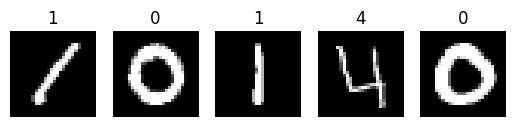

In [8]:
import matplotlib.pyplot as plt

for i in range(5):
    image = X.iloc[i].values.reshape(28, 28)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')

plt.show()

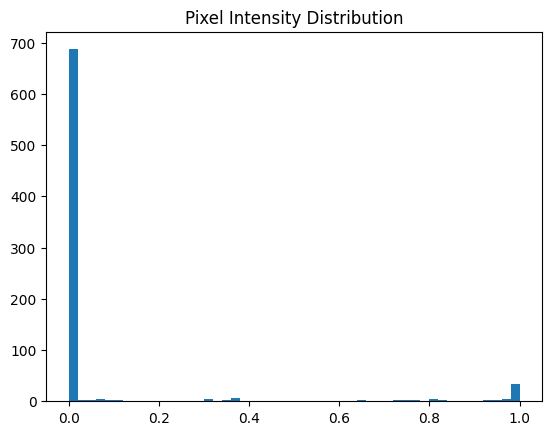

In [9]:
import matplotlib.pyplot as plt

plt.hist(X.iloc[0], bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()